In [2]:
import pandas as pd
import signatureanalyzer as sa

In [ ]:
# This maf was created by (1) taking the union of SNVs/indels for multiple tumors, (2) removing duplicates based on 'Chromosome', 'Start_position', 'Tumor_Sample_Barcode', 'Tumor_Seq_Allele2'
maf = pd.read_csv('../data/01262026_analysis_public_os_data_lowP_multiT_cleaned_mafs.tsv', sep='\t', index_col=0)
maf['Union_Sample_Name'].value_counts()

Union_Sample_Name
SJOS001101_M1-SJOS001101_G1-MT-union         50582
41T01-41N03-MT-union                         31126
SAMN03223715-SAMN03223750                    23264
39T01-39N01-MT-union                         22962
SJOS030579_D2-SJOS030579_G1                  21351
                                             ...  
TARGET-40-PARFTG-01A-TARGET-40-PARFTG-10A      360
TARGET-40-PASKZZ-01A-TARGET-40-PASKZZ-10A      358
TARGET-40-0A4I42-01A-TARGET-40-0A4I42-10A      290
TARGET-40-PALECC-01A-TARGET-40-PALECC-10A      215
TARGET-40-PANZHX-01A-TARGET-40-PANZHX-10A      199
Name: count, Length: 205, dtype: int64

In [3]:
maf = maf.reset_index(drop=True)
maf = maf.drop(columns=['Tumor_Sample_Barcode', 'Protein_Change', 'ref_context'])
maf.rename(columns={'Union_Sample_Name': 'Tumor_Sample_Barcode'}, inplace=True)
maf.rename(columns={'Start_position': 'Start_Position', 'End_position': 'End_Position'}, inplace=True)
maf['Chromosome'] = maf['Chromosome'].str.replace('chr', '')
maf

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,t_alt_count,t_ref_count,n_alt_count,n_ref_count,Tumor_Sample_Barcode
0,GABRG1,4,46098961,46098961,Intron,SNP,C,C,T,16,25,0,30,09T02-09N01-MT-union
1,Unknown,4,46582786,46582786,IGR,DEL,C,C,-,16,19,0,39,09T02-09N01-MT-union
2,Unknown,4,47013722,47013722,IGR,SNP,A,A,T,20,30,0,46,09T02-09N01-MT-union
3,GABRB1,4,47330864,47330864,Intron,SNP,T,T,G,6,35,0,34,09T02-09N01-MT-union
4,GABRB1,4,47417684,47417684,Intron,SNP,C,C,G,20,32,0,38,09T02-09N01-MT-union
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188044,Unknown,8,5618980,5618980,IGR,SNP,C,C,T,4,64,0,27,WGS_15_2-WGS_16_2
1188045,ENSG00000253880,8,6073563,6073563,RNA,SNP,T,T,C,5,56,0,49,WGS_15_2-WGS_16_2
1188046,Unknown,8,6340934,6340934,IGR,SNP,T,T,C,4,63,0,34,WGS_15_2-WGS_16_2
1188047,Unknown,8,8614611,8614611,IGR,SNP,T,T,G,6,63,1,42,WGS_15_2-WGS_16_2


In [4]:
maf.to_csv('../data/snv_filtered.maf', sep='\t', index=False)

   * Creating output dir at ./ardnmf_output/
   * Using hg38 build
   * Using cosmic3 signatures
   * Loading spectra from snv_filtered.maf
      * Mapping contexts: 1083127 / 1083128
   * Saving ARD-NMF outputs to ./ardnmf_output/nmf_output.h5
   * Running ARD-NMF...
	0/9: nit=10000 K=23 	del=0.00004597
	1/9: nit=10000 K=24 	del=0.00005757
	2/9: nit=10000 K=24 	del=0.00003968
	3/9: nit=10000 K=25 	del=0.00000834
	4/9: nit=10000 K=22 	del=0.00001590
	5/9: nit=10000 K=23 	del=0.00010790
	6/9: nit=10000 K=23 	del=0.00001225
	7/9: nit=10000 K=24 	del=0.00012069
	8/9: nit=10000 K=23 	del=0.00003456
	9/9: nit=10000 K=23 	del=0.00002059
   * Run 6 had lowest objective with mode (n=5) K = 23.
   * Saving report plots to ./ardnmf_output/
Plotting cosmic3 Attributions Barplot:
Plotting K Histogram:
Plotting cosmic3 Cosine Similarity:


/home/shreyaraman/sigs-env/lib/python3.9/site-packages/signatureanalyzer/plotting/_nmf.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=18)


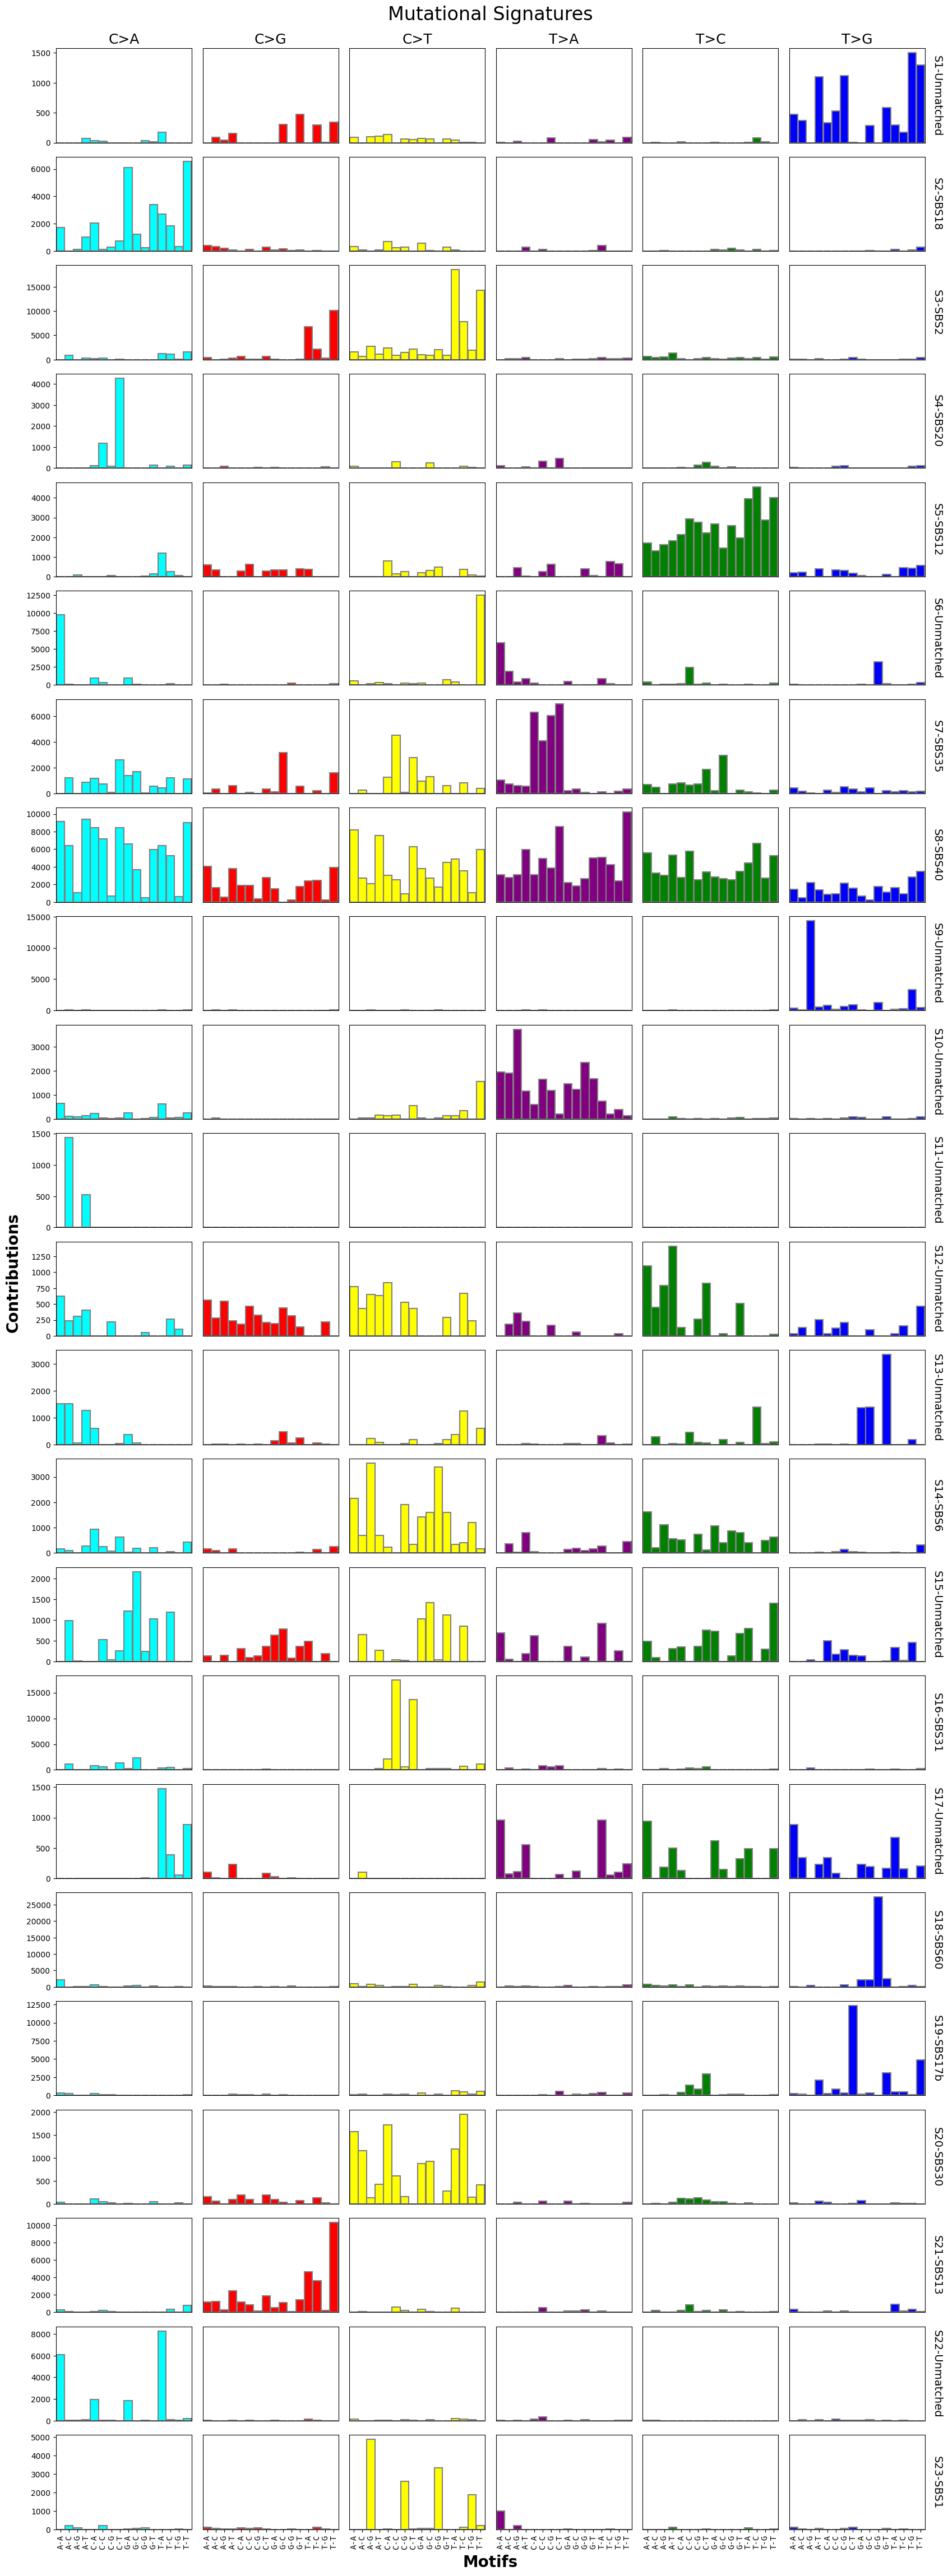

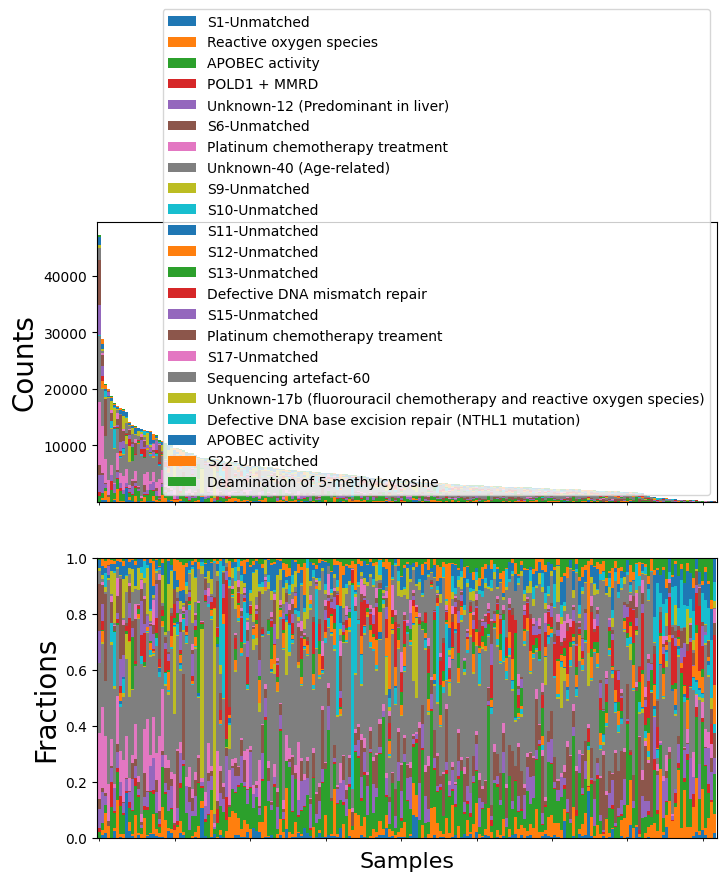

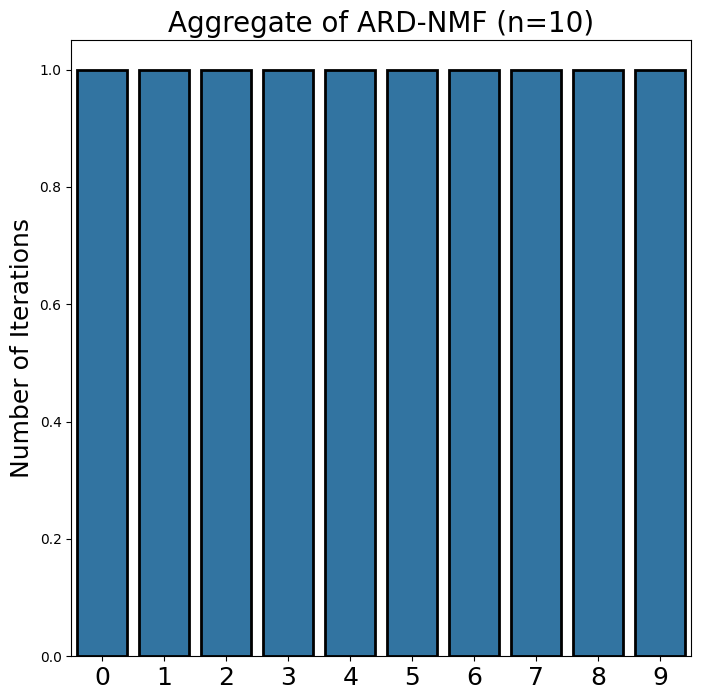

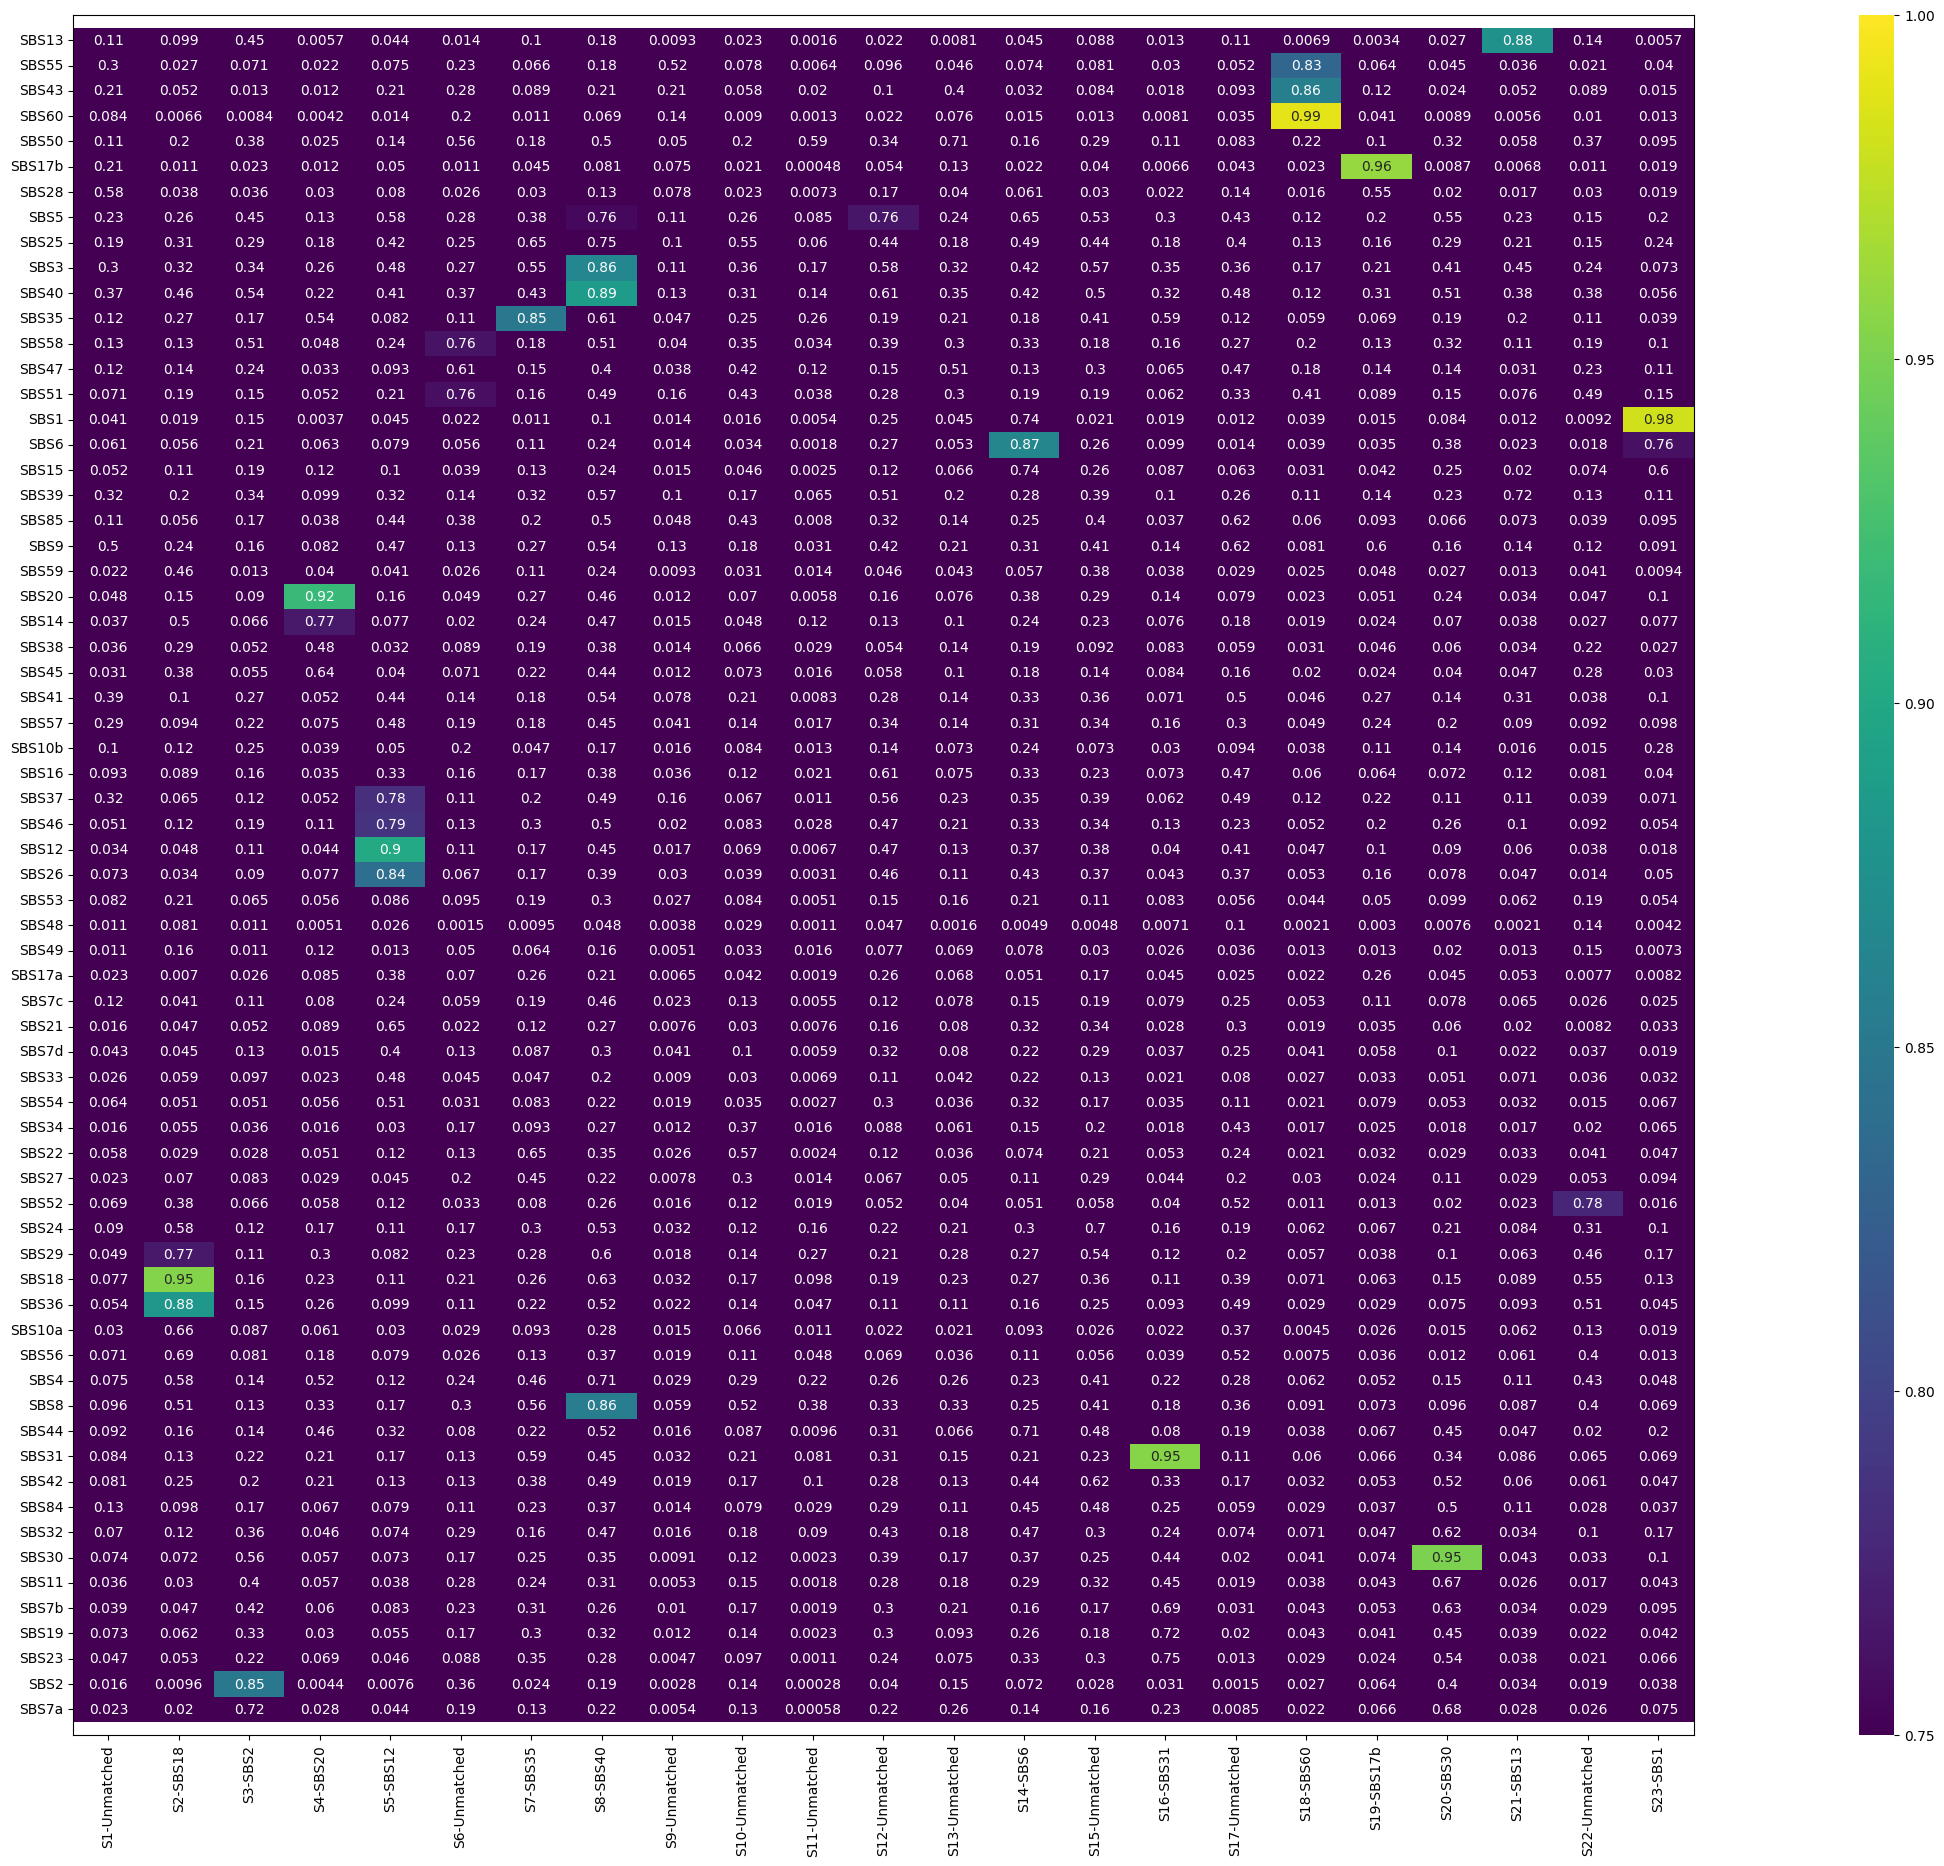

In [ ]:
sa.run_maf('../data/snv_filtered.maf', outdir='../outputs/ardnmf_output/', reference='cosmic3', hg_build='../data/hg38.2bit', nruns=10)